STAlign test


In [25]:
# import dependencies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import math
import yaml

# make plots bigger
plt.rcParams["figure.figsize"] = (12,10)

In [26]:
# OPTION A: import STalign after pip or pipenv install
from STalign import STalign

In [ ]:
with open("parameters/lungTMA1.yml", 'r') as file:
        arguments = yaml.safe_load(file)

Import image

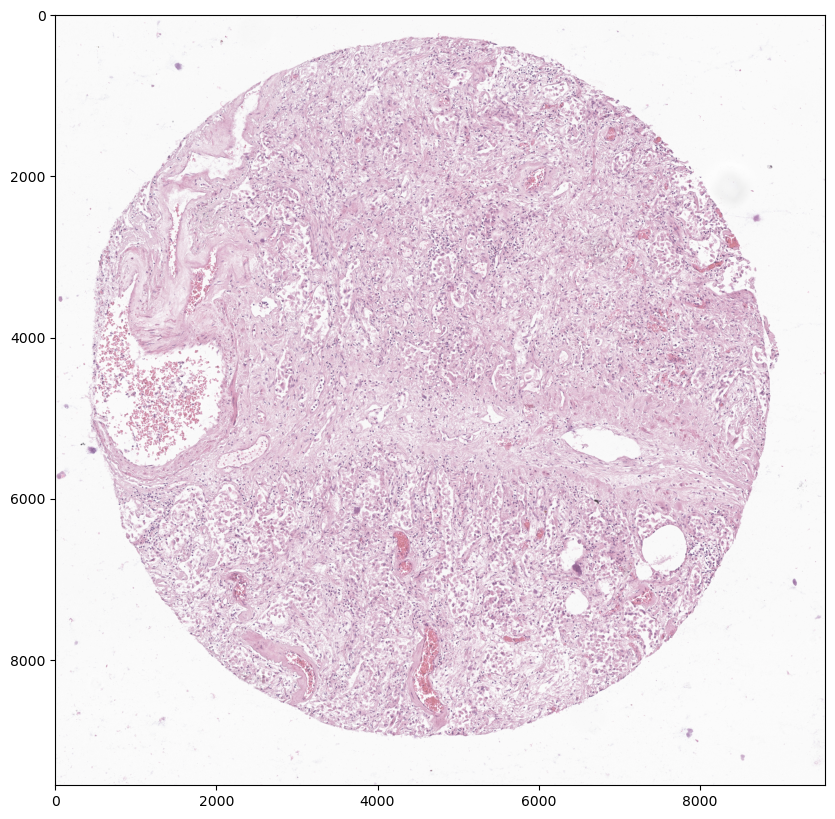

In [28]:
# Target is H&E staining image
image_file = arguments["target_image"]
V = plt.imread(image_file)
fig,ax = plt.subplots()
ax.imshow(V)

In [29]:
print(V.shape)
print(V.min())
print(V.max())

(9557, 9557, 3)
44
255


In [30]:
# normalize
Inorm = STalign.normalize(V)

print(Inorm.min())
print(Inorm.max())

# get extent
YI = np.array(range(I.shape[1]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
XI = np.array(range(I.shape[2]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
extentI = STalign.extent_from_x((XI,YI))
extentI

0.0
1.0


(-0.5, 9556.5, 9556.5, -0.5)

In [ ]:
I = Inorm.transpose(2,0,1)
print(I.shape)

# get extent
YI = np.array(range(I.shape[1]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
XI = np.array(range(I.shape[2]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
extentI = STalign.extent_from_x((XI,YI))

(3, 9557, 9557)


(-0.5, 9556.5, 9556.5, -0.5)

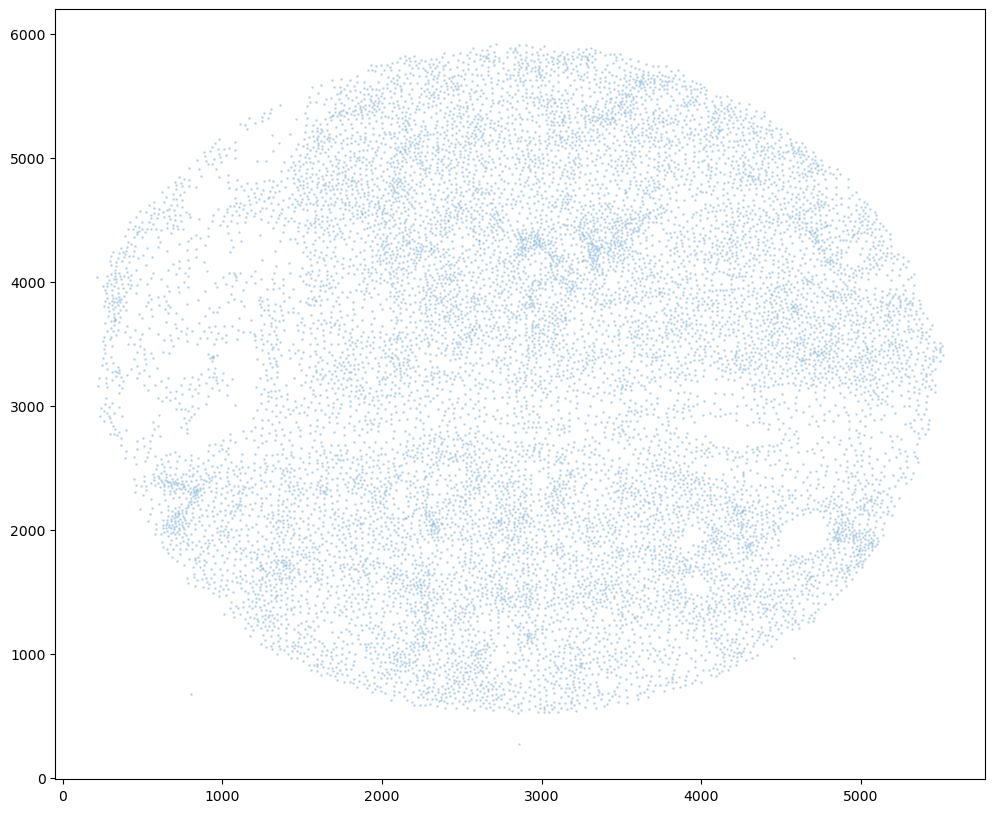

In [32]:
# Single cell data to be aligned
fname = arguments["cells"]
df = pd.read_csv(fname)
xM = np.array(df['x'])
yM = np.array(df['y'])
df.head()

# get cell centroid coordinates
xM = np.array(df['x'])
yM = np.array(df['y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xM,yM,s=1,alpha=0.2)

plot together

0 of 13946
10000 of 13946
13945 of 13946


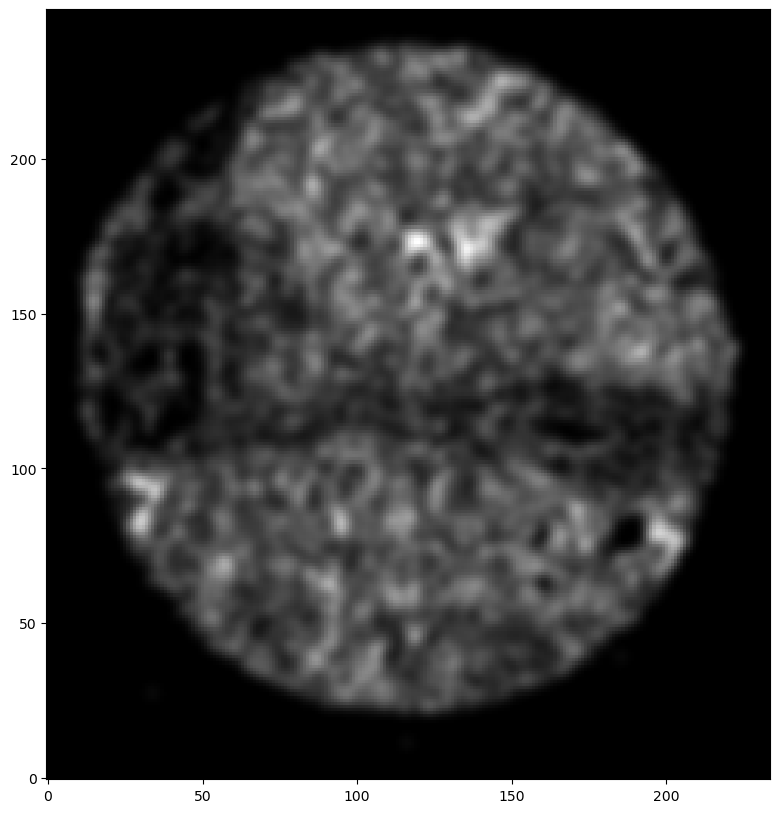

In [33]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XJ,YJ,M,fig = STalign.rasterize(xM, yM, dx=25)
J = np.vstack((M, M, M))
ax = fig.axes[0]
ax.invert_yaxis()

In [46]:
np.savez(arguments["target_annotator_image"], x=XI,y=YI,I=I)
np.savez(arguments["source_annotator_image"], x=XJ,y=YJ,I=J)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


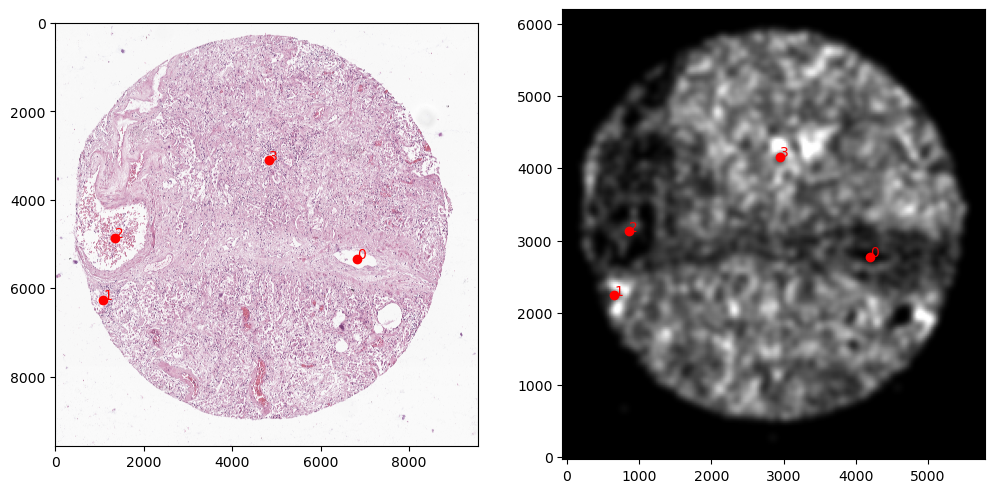

In [42]:
# manually make corresponding points
pointsI = pd.read_csv(arguments["affine_target_landmarks"])
pointsI = pointsI[["y", "x"]].to_numpy()
pointsJ = pd.read_csv(arguments["affine_source_landmarks"])
pointsJ = pointsJ[["y", "x"]].to_numpy()

# plot
extentJ = STalign.extent_from_x((YJ,XJ))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='red')
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='red')
for i in range(pointsI.shape[0]):
    ax[0].text(pointsI[i,1],pointsI[i,0],f'{i}', c='red')
    ax[1].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='red')

# invert only rasterized image
ax[1].invert_yaxis()